In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)
N=3000
x1=np.random.uniform(-2,2,N)
x2=np.random.uniform(-2,2,N)
X=np.stack([x1,x2],axis=1)
y=((x1**2+x2**2)>1.5).astype(int).reshape(-1,1)
p=np.random.permutation(N)
X=X[p];y=y[p]
n1=int(0.7*N);n2=int(0.85*N)
Xtr=X[:n1];ytr=y[:n1]
Xva=X[n1:n2];yva=y[n1:n2]
Xte=X[n2:];yte=y[n2:]

In [3]:
def relu(z):return np.maximum(0,z)
def relud(z):return (z>0).astype(float)
def sigmoid(z):return 1/(1+np.exp(-z))
def sigmoidd(z):s=sigmoid(z);return s*(1-s)


In [4]:
def init(l):
 W=[];b=[]
 for i in range(len(l)-1):
  W.append(np.random.uniform(-0.5,0.5,(l[i],l[i+1])))
  b.append(np.zeros((1,l[i+1])))
 return W,b


In [5]:
def forward(X,W,b,act):
 A=X
 Zs=[];As=[A]
 for i in range(len(W)-1):
  Z=A@W[i]+b[i]
  A=act(Z)
  Zs.append(Z);As.append(A)
 Z=A@W[-1]+b[-1]
 A=sigmoid(Z)
 Zs.append(Z);As.append(A)
 return Zs,As


In [6]:
def bce(y,p):
 e=1e-8
 p=np.clip(p,e,1-e)
 return -np.mean(y*np.log(p)+(1-y)*np.log(1-p))


In [7]:
def backward(X,y,W,b,Zs,As,actd):
 m=X.shape[0]
 dWs=[0]*len(W);dbs=[0]*len(b)
 dA=As[-1]-y
 for i in reversed(range(len(W))):
  if i==len(W)-1:
   dZ=dA
  else:
   dZ=dA*actd(Zs[i])
  dW=As[i].T@dZ/m
  db=np.sum(dZ,axis=0,keepdims=True)/m
  dA=dZ@W[i].T
  dWs[i]=dW;dbs[i]=db
 return dWs,dbs


In [8]:
def acc(y,p):
 return np.mean((p>=0.5)==y)


In [9]:
def train(layers,act,actd,opt="sgd",lr=0.01,ep=50):
 W,b=init(layers)
 v=[np.zeros_like(w) for w in W]
 trl=[];val=[]
 for e in range(ep):
  Zs,As=forward(Xtr,W,b,act)
  dW,db=backward(Xtr,ytr,W,b,Zs,As,actd)
  for i in range(len(W)):
   if opt=="momentum":
    v[i]=0.9*v[i]+lr*dW[i]
    W[i]=W[i]-v[i]
   else:
    W[i]=W[i]-lr*dW[i]
   b[i]=b[i]-lr*db[i]
  p=As[-1]
  trl.append(bce(ytr,p))
  pv=forward(Xva,W,b,act)[1][-1]
  val.append(bce(yva,pv))
 plt.plot(trl)
 plt.plot(val)
 plt.show()
 pt=forward(Xte,W,b,act)[1][-1]
 print(acc(ytr,p),acc(yva,pv),acc(yte,pt))


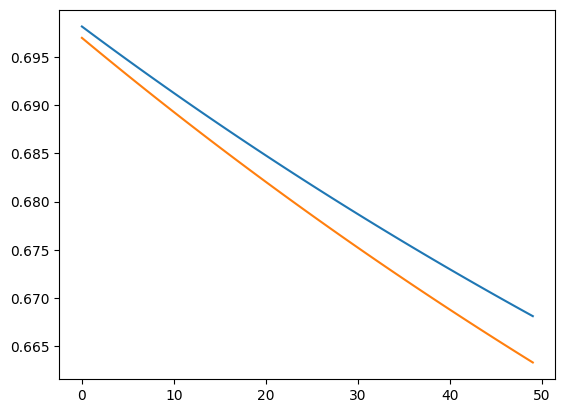

0.7042857142857143 0.7355555555555555 0.7


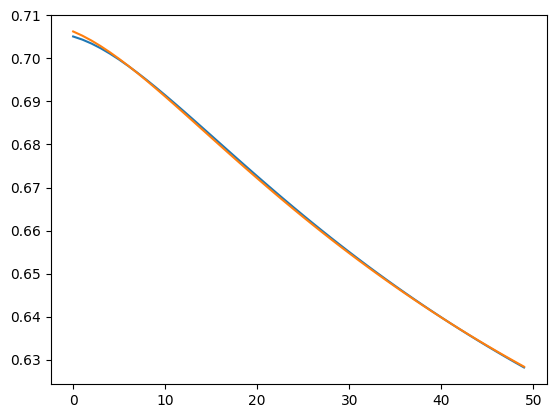

0.7071428571428572 0.7355555555555555 0.7


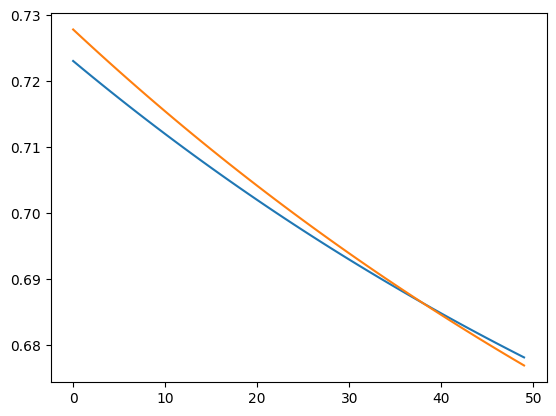

0.5128571428571429 0.5288888888888889 0.5222222222222223


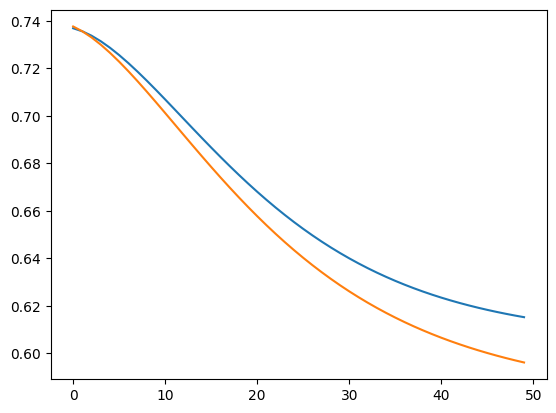

0.7071428571428572 0.7355555555555555 0.7


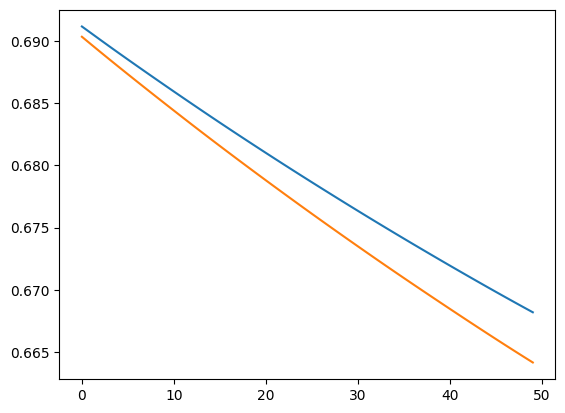

0.7071428571428572 0.7355555555555555 0.7


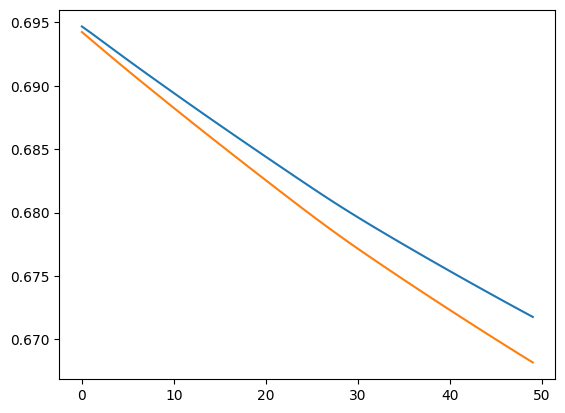

0.7071428571428572 0.7355555555555555 0.7


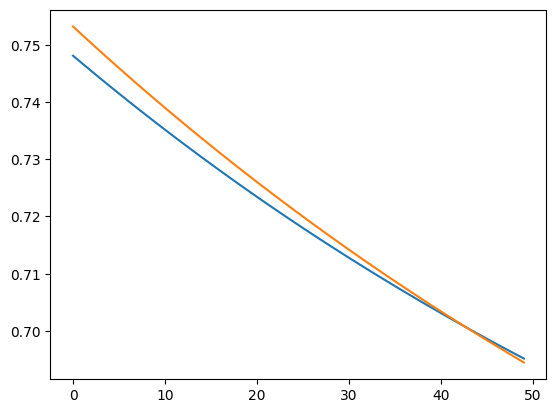

0.29285714285714287 0.2644444444444444 0.3


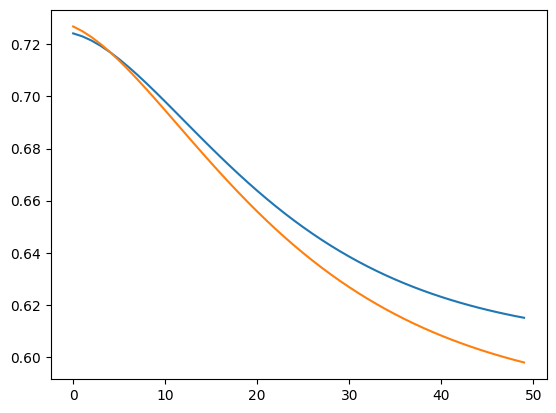

0.7071428571428572 0.7355555555555555 0.7


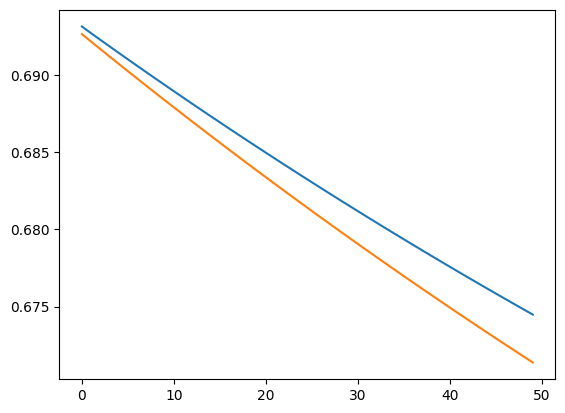

0.7071428571428572 0.7355555555555555 0.7


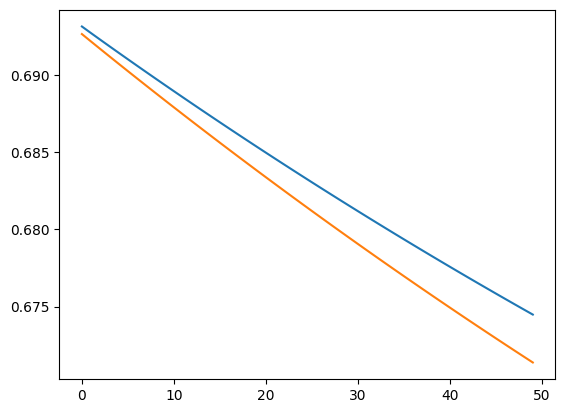

0.7071428571428572 0.7355555555555555 0.7


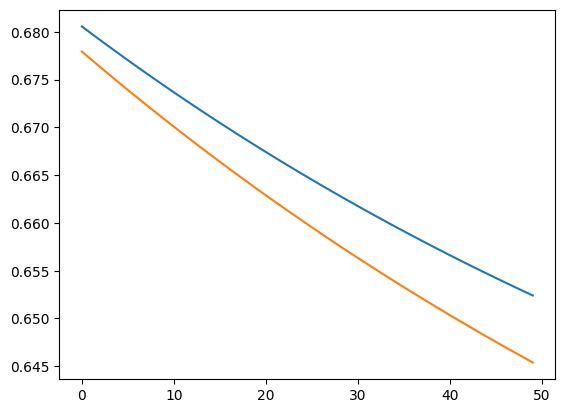

0.7071428571428572 0.7355555555555555 0.7


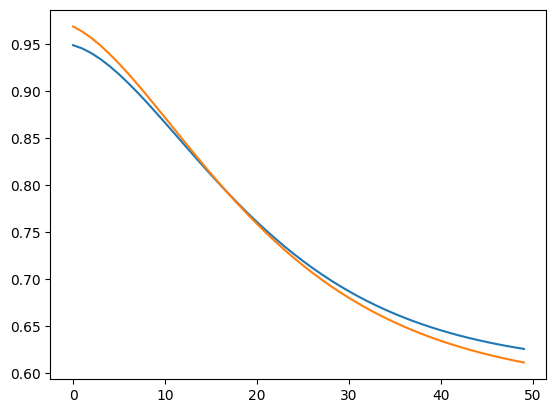

0.7071428571428572 0.7355555555555555 0.7


In [10]:
models=[[2,4,1],[2,4,4,4,4,1],[2,4,4,4,4,4,4,4,4,4,1]]
for m in models:
 train(m,relu,relud,"sgd")
 train(m,relu,relud,"momentum")
 train(m,sigmoid,sigmoidd,"sgd")
 train(m,sigmoid,sigmoidd,"momentum")
